# Контрольная работа
## Предварительный анализ данных

Вариант 2. Набор данных drivers.csv.

Выполнил: В. В. Воронов. Группа: 4311з.

Дисциплина: Введение в анализ данных. Кафедра прикладной информатики (№ 41).

Преподаватель: В. В. Боженко.

Цель работы: выполнить предварительную обработку табличных данных перед дальнейшим анализом: проверить структуру, типы, пропуски и дубликаты, привести поля к корректным типам и подготовить очищенный набор.

Ссылка на репозиторий с ноутбуком: https://github.com/vvvl36/vad_lab_1_var_2.

## 1 Загрузка датасета и первые строки

Файл drivers.csv содержит записи о поездках. В каждой строке указаны время начала и окончания поездки, категория, места отправления и назначения, расстояние в милях и цель поездки.

Размер таблицы: (161, 7)
Первые 20 строк:
      START_DATE         END_DATE CATEGORY*       START          STOP   MILES   PURPOSEroute
01.10.2016 19:12 01.10.2016 19:32  Business     Midtown   East Harlem 44963.0        MEETING
01.11.2016 13:32 01.11.2016 13:46  Business     Midtown  Midtown East 45108.0 Meal/Entertain
01.12.2016 12:33 01.12.2016 12:49  Business     Midtown Hudson Square 45170.0 Meal/Entertain
 1.13.2016 15:00  1.13.2016 15:28  Business     Gulfton      Downtown 45149.0        Meeting
 1.29.2016 21:21  1.29.2016 21:40  Business        Apex          Cary 45051.0 Meal/Entertain
 1.30.2016 18:09  1.30.2016 18:24  Business        Apex          Cary 45112.0 Customer Visit
02.01.2016 12:10 02.01.2016 12:43  Business Chapel Hill          Cary 45008.0 Customer Visit
 02.04.2016 9:37 02.04.2016 10:09  Business Morrisville          Cary 45116.0 Meal/Entertain
02.07.2016 18:03 02.07.2016 18:17  Business        Apex          Cary 45112.0 Customer Visit
02.07.2016 20:22 02.07.2016 

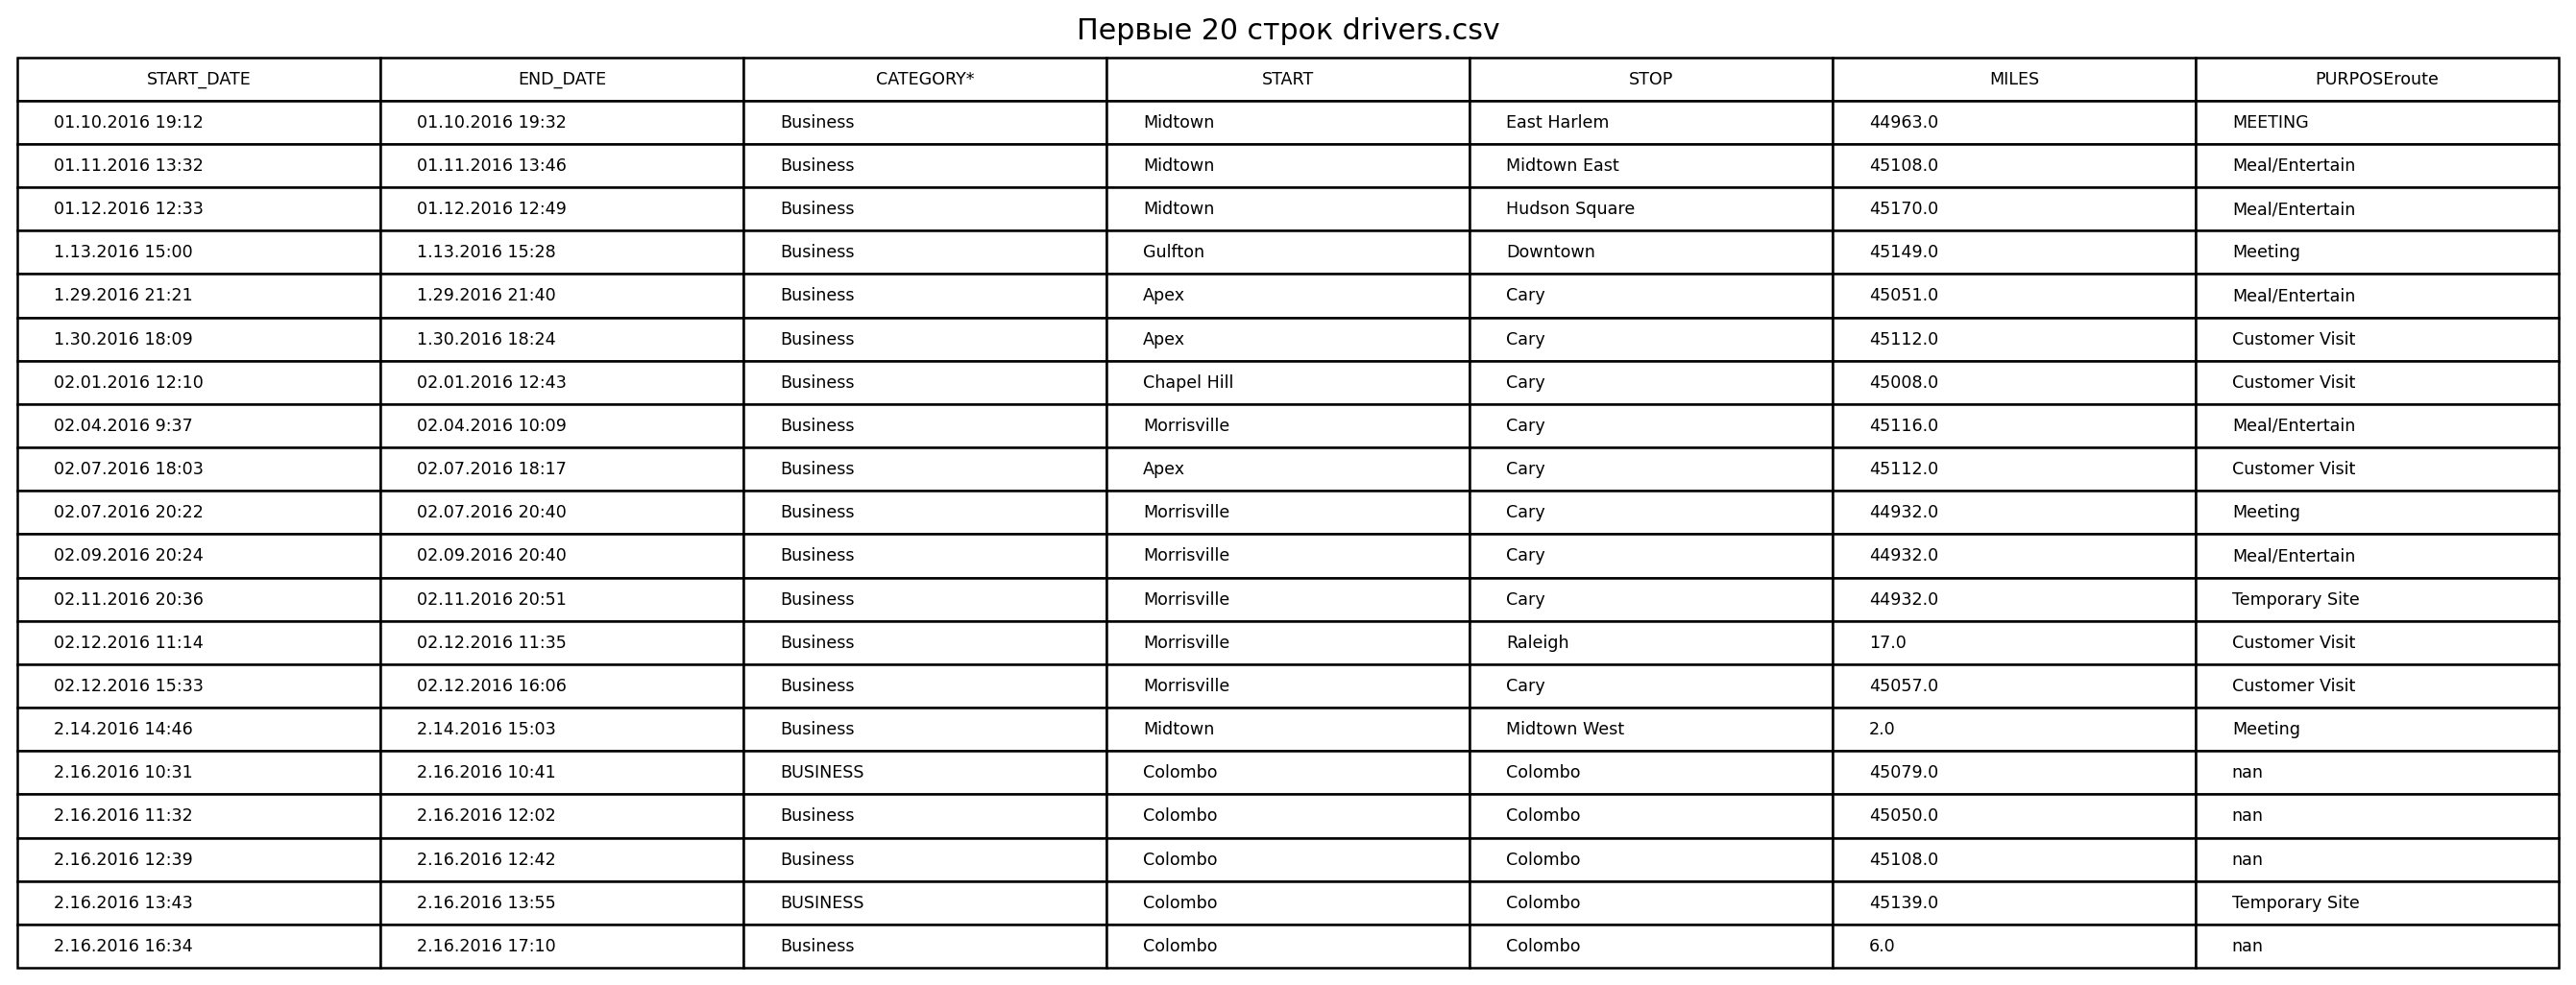

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import io
from pathlib import Path
from common_drivers import load_raw, preprocess, save_cleaned
raw = load_raw('drivers.csv')
df = raw.copy()
print('Размер таблицы:', df.shape)
print('Первые 20 строк:')
print(df.head(20).to_string(index=False))
df.head(20).to_csv('results/head20.csv', sep=';', encoding='utf-8-sig', index=False)
fig, ax = plt.subplots(figsize=(15, 5.8))
ax.axis('off')
table = ax.table(cellText=df.head(20).astype(str).values,
                 colLabels=df.columns, loc='center', cellLoc='left')
table.auto_set_font_size(False); table.set_fontsize(7); table.scale(1, 1.35)
ax.set_title('Первые 20 строк drivers.csv', pad=18)
fig.tight_layout()
fig.savefig('figures/head20.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 2 Описание предметной области

Набор относится к предметной области поездок на такси. Наблюдением является одна поездка. Даты позволяют определить момент и длительность поездки, CATEGORY характеризует деловую или личную поездку, START и STOP — точки маршрута, MILES — расстояние, PURPOSE — цель поездки. Поля START и STOP рассматриваются как категориальные названия мест; методичка разрешает не проверять их на неявные дубликаты.

In [2]:
description = pd.DataFrame({
    'Поле': ['START_DATE', 'END_DATE', 'CATEGORY*', 'START', 'STOP', 'MILES', 'PURPOSEroute'],
    'Смысл': ['дата и время начала', 'дата и время окончания', 'категория поездки',
              'место начала', 'место окончания', 'пройденные мили', 'цель поездки'],
    'Тип после обработки': ['datetime', 'datetime', 'category', 'string', 'string',
                             'float', 'category']
})
print(description.to_string(index=False))
description.to_csv('results/column_description.csv', sep=';', encoding='utf-8-sig', index=False)

        Поле                  Смысл Тип после обработки
  START_DATE    дата и время начала            datetime
    END_DATE дата и время окончания            datetime
   CATEGORY*      категория поездки            category
       START           место начала              string
        STOP        место окончания              string
       MILES        пройденные мили               float
PURPOSEroute           цель поездки            category


## 3 Оценка структуры методом info

Метод info показывает количество строк, названия полей, типы данных и число непустых значений. На этом этапе пропуски в цели поездки ещё не заменяются, чтобы зафиксировать исходное состояние.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   START_DATE    161 non-null    object 
 1   END_DATE      161 non-null    object 
 2   CATEGORY*     161 non-null    object 
 3   START         161 non-null    object 
 4   STOP          161 non-null    object 
 5   MILES         161 non-null    float64
 6   PURPOSEroute  84 non-null     object 
dtypes: float64(1), object(6)
memory usage: 8.9+ KB


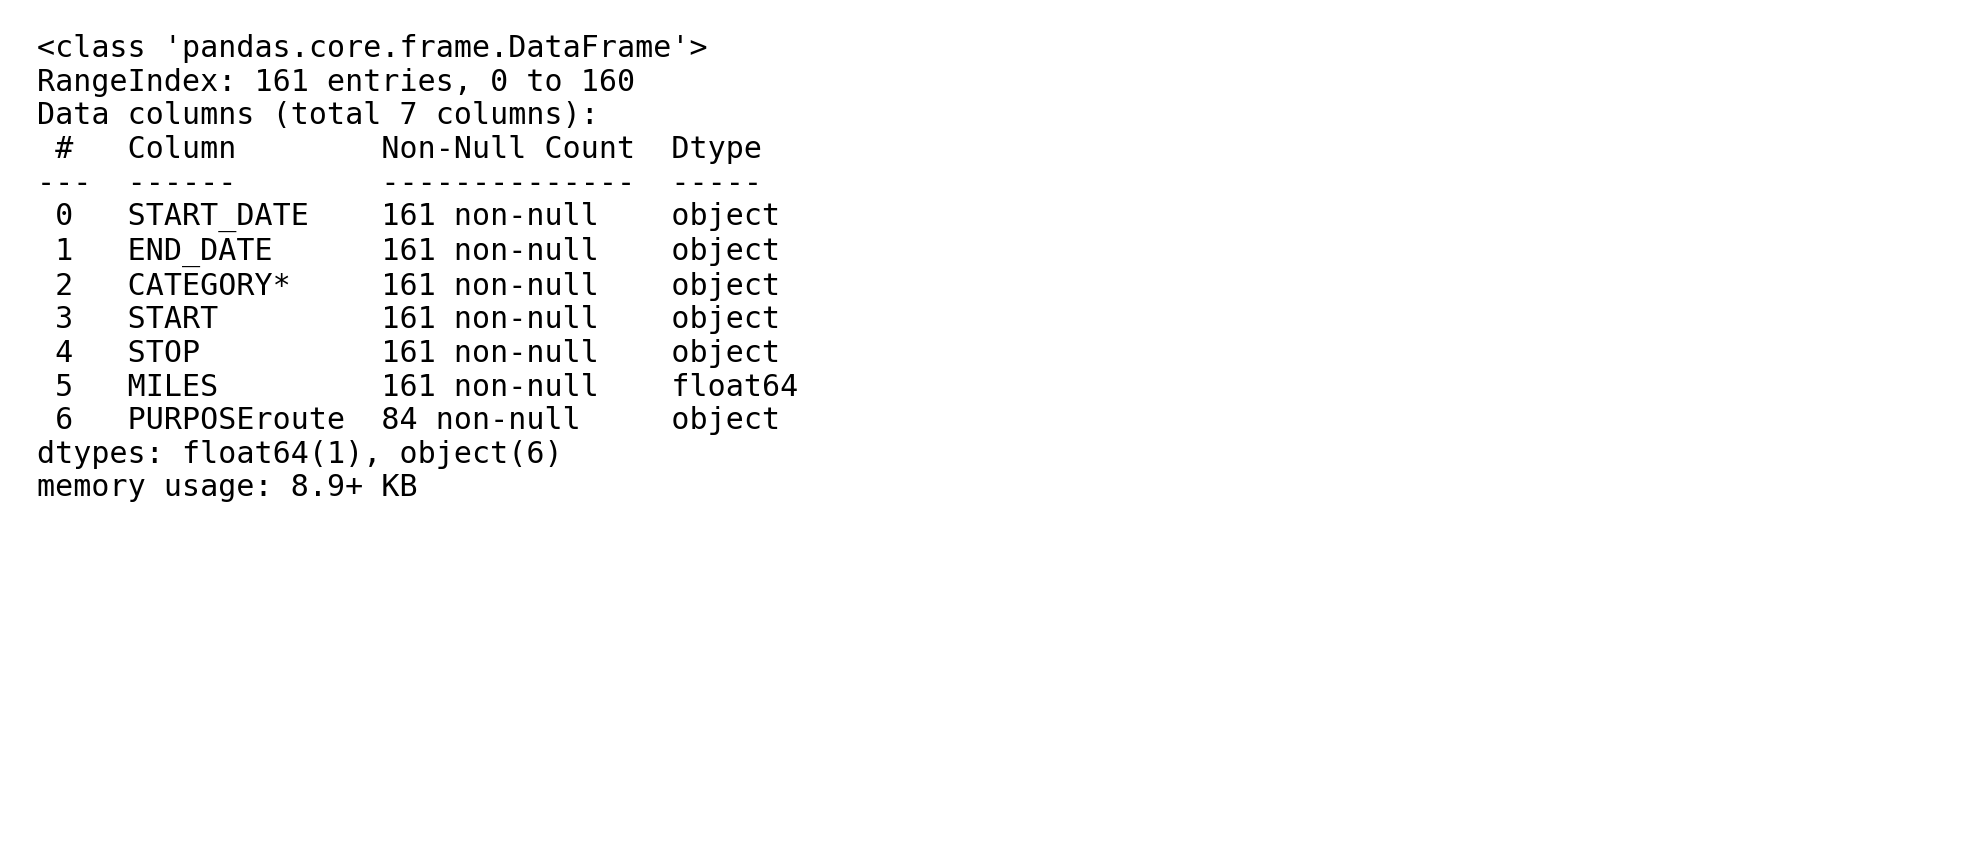

In [3]:
buffer = io.StringIO()
df.info(buf=buffer)
info_text = buffer.getvalue()
print(info_text, end='')
Path('results/info.txt').write_text(info_text, encoding='utf-8')
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.axis('off')
ax.text(0.01, 0.98, info_text, va='top', ha='left', family='DejaVu Sans Mono', fontsize=12)
fig.tight_layout()
fig.savefig('figures/info.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 4 Описательная статистика числовых столбцов

Метод describe применён к исходному числовому полю MILES. Большие значения в этом поле выглядят как серийные номера дат Excel, поэтому статистика до восстановления расстояний отражает особенности кодировки, а не реальный масштаб маршрутов.

       count          mean           std  min      25%      50%      75%      max
MILES  161.0  37766.519255  16614.925558  0.8  44931.0  45008.0  45081.0  45177.0


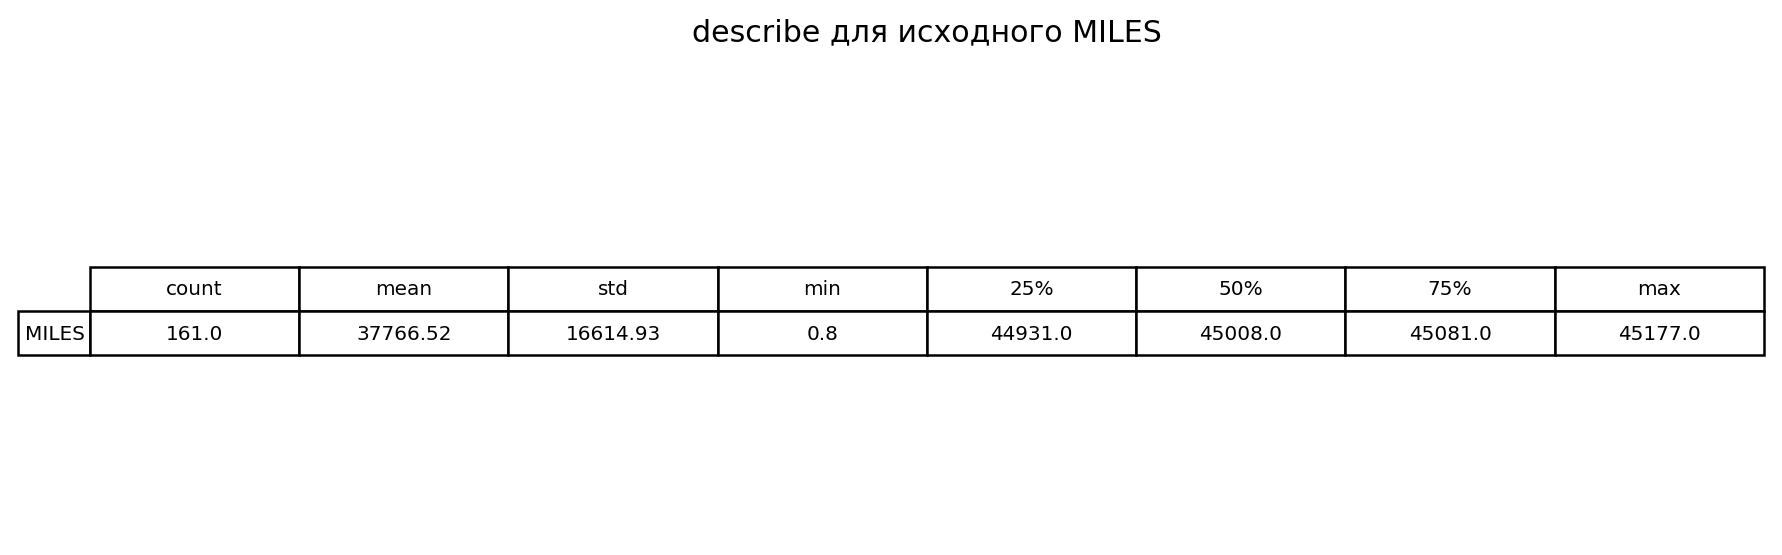

In [4]:
describe_raw = df.describe(include='number').T
print(describe_raw.to_string())
describe_raw.to_csv('results/describe_raw.csv', sep=';', encoding='utf-8-sig')
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')
tbl = ax.table(cellText=describe_raw.round(2).astype(str).values,
               rowLabels=describe_raw.index, colLabels=describe_raw.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.45)
ax.set_title('describe для исходного MILES', pad=18)
fig.tight_layout()
fig.savefig('figures/describe.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 5 Проверка и исправление названий столбцов

Названия CATEGORY* и PURPOSEroute содержат технические символы и не соответствуют единому стилю. Они заменены на CATEGORY и PURPOSE. Остальные названия понятны и сохранены.

In [5]:
print('До переименования:', list(df.columns))
df = df.rename(columns={'CATEGORY*': 'CATEGORY', 'PURPOSEroute': 'PURPOSE'})
print('После переименования:', list(df.columns))
pd.DataFrame({'column_before': ['CATEGORY*', 'PURPOSEroute'],
              'column_after': ['CATEGORY', 'PURPOSE']}).to_csv(
    'results/renamed_columns.csv', sep=';', encoding='utf-8-sig', index=False)

До переименования: ['START_DATE', 'END_DATE', 'CATEGORY*', 'START', 'STOP', 'MILES', 'PURPOSEroute']
После переименования: ['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES', 'PURPOSE']


## 6 Обработка пропусков

Пропуски найдены только в поле PURPOSE. Удаление строк привело бы к потере поездок, поэтому пропуски заменены на нейтральную категорию «Не указана». Такое решение позволяет сохранить количество наблюдений и явно отличать неизвестную цель от известных целей.

In [6]:
missing_before = df.isna().sum()
print('Пропуски до обработки:')
print(missing_before.to_string())
df['PURPOSE'] = df['PURPOSE'].fillna('Не указана')
missing_after = df.isna().sum()
print('Пропуски после обработки:')
print(missing_after.to_string())
pd.DataFrame({'before': missing_before, 'after': missing_after}).to_csv(
    'results/missing_before_after.csv', sep=';', encoding='utf-8-sig')

Пропуски до обработки:
START_DATE     0
END_DATE       0
CATEGORY       0
START          0
STOP           0
MILES          0
PURPOSE       77
Пропуски после обработки:
START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0


## 7 Проверка явных и неявных дубликатов

Два полных дубликата удаляются методом drop_duplicates. В текстовых полях обнаружены неявные дубликаты: BUSINESS и Business, MEETING и Meeting обозначают одинаковые значения. Поля CATEGORY и PURPOSE нормализованы методом title. Названия мест START и STOP не объединяются без подтверждённого справочника.

In [7]:
explicit_before = int(df.duplicated().sum())
print('Полных дубликатов до удаления:', explicit_before)
print('Варианты CATEGORY до нормализации:', sorted(df['CATEGORY'].dropna().unique().tolist()))
print('Варианты PURPOSE до нормализации:', sorted(df['PURPOSE'].dropna().unique().tolist()))
df['CATEGORY'] = df['CATEGORY'].str.title()
df['PURPOSE'] = df['PURPOSE'].str.title()
df = df.drop_duplicates().reset_index(drop=True)
print('Полных дубликатов после удаления:', int(df.duplicated().sum()))
print('Размер после удаления:', df.shape)
pd.DataFrame({'explicit_duplicates_before': [explicit_before],
              'rows_after_drop_duplicates': [len(df)]}).to_csv(
    'results/duplicates.csv', sep=';', encoding='utf-8-sig', index=False)

Полных дубликатов до удаления: 2
Варианты CATEGORY до нормализации: ['BUSINESS', 'Business', 'Personal']
Варианты PURPOSE до нормализации: ['Customer Visit', 'MEETING', 'Meal/Entertain', 'Meeting', 'Moving', 'Temporary Site', 'Не указана']
Полных дубликатов после удаления: 0
Размер после удаления: (159, 7)


## 8 Приведение типов и формирование обработанного набора

Даты преобразуются в datetime с форматом месяц.день.год, который используется в исходном файле. Длительность поездки рассчитывается в минутах. MILES сохраняется в исходном виде в MILES_RAW, а значения, выглядящие как серийные даты Excel, восстанавливаются в отдельное числовое поле MILES. Такой подход не скрывает исходную кодировку и позволяет использовать подготовленные значения в следующих работах.

In [8]:
clean_df, audit = preprocess(raw)
save_cleaned(clean_df, 'drivers_cleaned.csv')
print('Типы после обработки:')
print(clean_df.dtypes.to_string())
print('Проверка дат: ошибок преобразования нет')
print('Неположительная длительность:', int((clean_df['DURATION_MIN'] <= 0).sum()))
print('Строк после очистки:', len(clean_df))
print('Удалено полных дублей:', audit['duplicate_count'])
print('Восстановлено расстояний:', audit['recovered_miles'])
print('Пропуски после обработки:')
print(clean_df.isna().sum().to_string())
clean_df.dtypes.astype(str).rename('dtype').to_csv(
    'results/dtypes_after.csv', sep=';', encoding='utf-8-sig')

Типы после обработки:
START_DATE             datetime64[ns]
END_DATE               datetime64[ns]
CATEGORY                       object
START                          object
STOP                           object
MILES                         float64
PURPOSE                        object
PURPOSE_WAS_MISSING              bool
DURATION_MIN                  float64
MILES_RAW                     float64
MILES_RECOVERED                  bool
START_HOUR                      int32
WEEKDAY                        object
SPEED_MPH                     float64
Проверка дат: ошибок преобразования нет
Неположительная длительность: 0
Строк после очистки: 159
Удалено полных дублей: 2
Восстановлено расстояний: 133
Пропуски после обработки:
START_DATE             0
END_DATE               0
CATEGORY               0
START                  0
STOP                   0
MILES                  0
PURPOSE                0
PURPOSE_WAS_MISSING    0
DURATION_MIN           0
MILES_RAW              0
MILES_RECOVERED   

## 9 Вывод по работе

Выполнена предварительная обработка исходного файла drivers.csv. В таблице было 161 наблюдение и 7 столбцов. В поле PURPOSE обнаружено 77 пропусков; они заменены значением «Не указана», поэтому строки не потеряны. Найдены 2 полных дубликата, которые удалены. Неявные дубликаты BUSINESS/Business и MEETING/Meeting устранены нормализацией регистра, а названия CATEGORY* и PURPOSEroute приведены к CATEGORY и PURPOSE.

Даты начала и окончания преобразованы в datetime, для каждой поездки рассчитана положительная длительность в минутах. Числовое поле MILES дополнительно проверено: 133 значения после удаления дублей выглядят как серийные номера дат Excel. Для дальнейшего анализа сохранено исходное поле MILES_RAW и восстановлено числовое MILES по явно указанной гипотезе. После обработки получен воспроизводимый набор drivers_cleaned.csv, пригодный для визуализации и группировки.

## 10 Использованные материалы

1. Контрольная работа «Предварительный анализ данных»: порядок проверки структуры, пропусков, дубликатов и типов.
2. Лабораторная работа 1 «Методы агрегации и группировки данных»: вариант 2 и описание drivers.csv.
3. В. В. Боженко, Т. М. Татарникова. Язык программирования Python для анализа данных. СПб.: ГУАП, 2023.
4. Введение в анализ данных: определения датасета, признаков и этапов анализа.
5. Предоставленный файл drivers.csv.